<a href="https://colab.research.google.com/github/HamzaEric/Heart_Diagnosis_MLP/blob/main/Notebooks/Feed_Forward_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feed Forward Neural Network

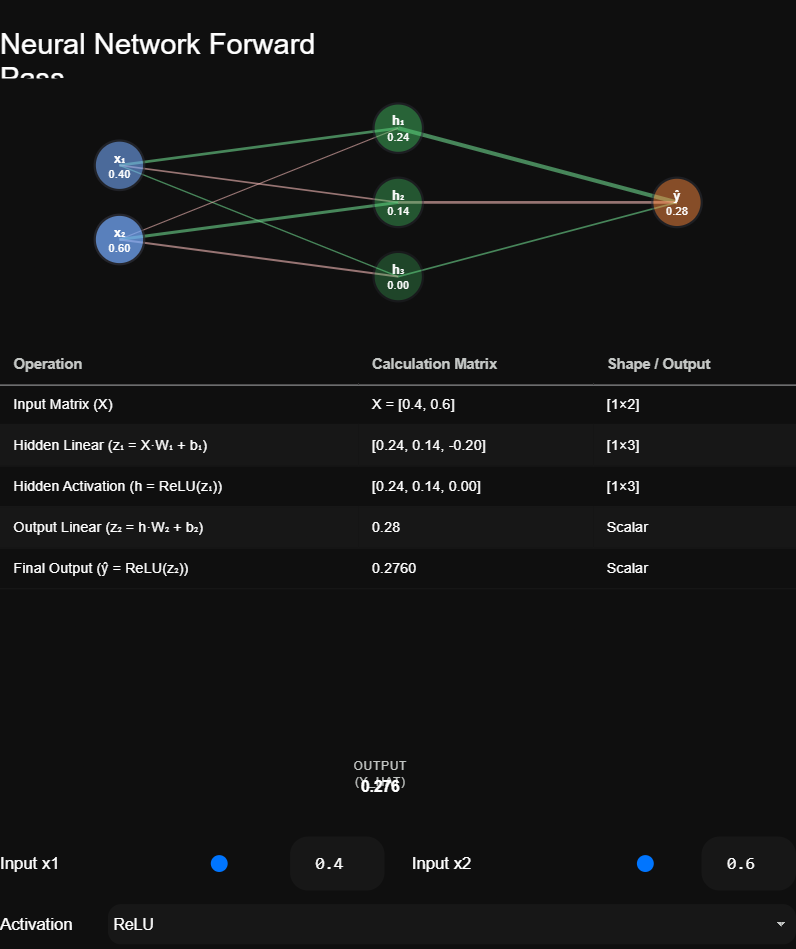

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

In [3]:
input_dim = 2
hidden_dim = 3
output_dim = 1


x = np.array([[1.5, -0.5]])



W1 = np.random.randn(input_dim, hidden_dim)  # (2 → 3)
b1 = np.random.randn(1, hidden_dim)

W2 = np.random.randn(hidden_dim, output_dim)  # (3 → 1)
b2 = np.random.randn(1, output_dim)

# Activation function: ReLU
def relu(z):
    return np.maximum(0, z)



# Forward pass
z1 = np.dot(x, W1) + b1      # Linear transform
h = relu(z1)                 # Apply activation
y_hat = np.dot(h, W2) + b2   # Output layer

print("Input:", x)
print("Hidden activations:", h)
print("Output prediction:", y_hat)

Input: [[ 1.5 -0.5]]
Hidden activations: [[0.85725885 1.09298957 0.        ]]
Output prediction: [[-1.61302056]]


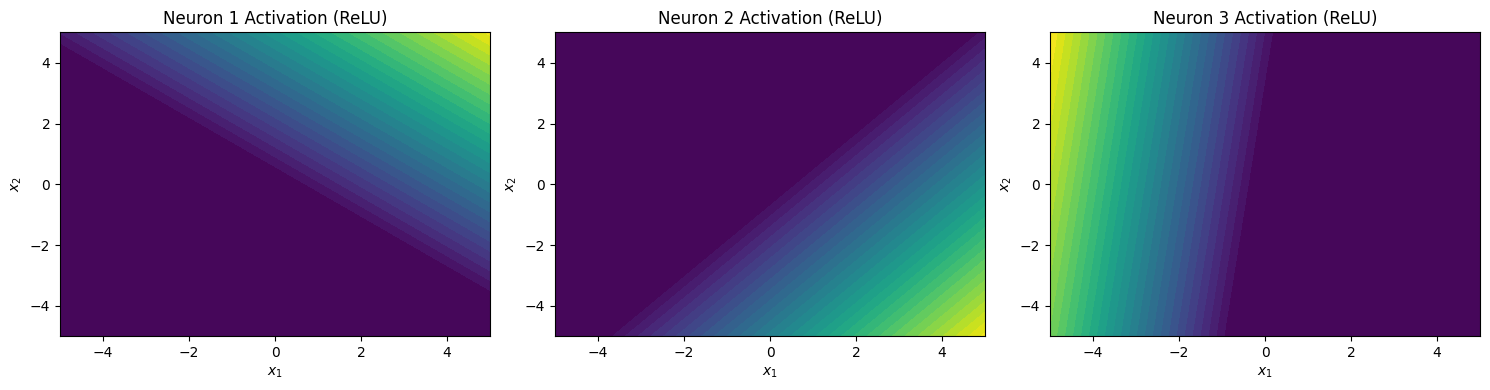

In [4]:
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(-5, 5, 200),
    np.linspace(-5, 5, 200)
)
grid_points = np.c_[grid_x1.ravel(), grid_x2.ravel()]  # shape (40000, 2)

# Forward pass through hidden layer
z1 = np.dot(grid_points, W1) + b1
h1 = relu(z1)

# Try sigmoid activation instead:
# h1 = sigmoid(z1)                   # shape (40000, 3)

# Try without activation for linear output
# h1 = z1                        # shape (40000, 3)

# Plot activation map for each hidden neuron
fig, axes = plt.subplots(1, hidden_dim, figsize=(15, 4))
for i in range(hidden_dim):
    ax = axes[i]
    h_vals = h1[:, i].reshape(grid_x1.shape)
    ax.contourf(grid_x1, grid_x2, h_vals, cmap='viridis', levels=30)
    ax.set_title(f'Neuron {i+1} Activation (ReLU)')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.show()

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

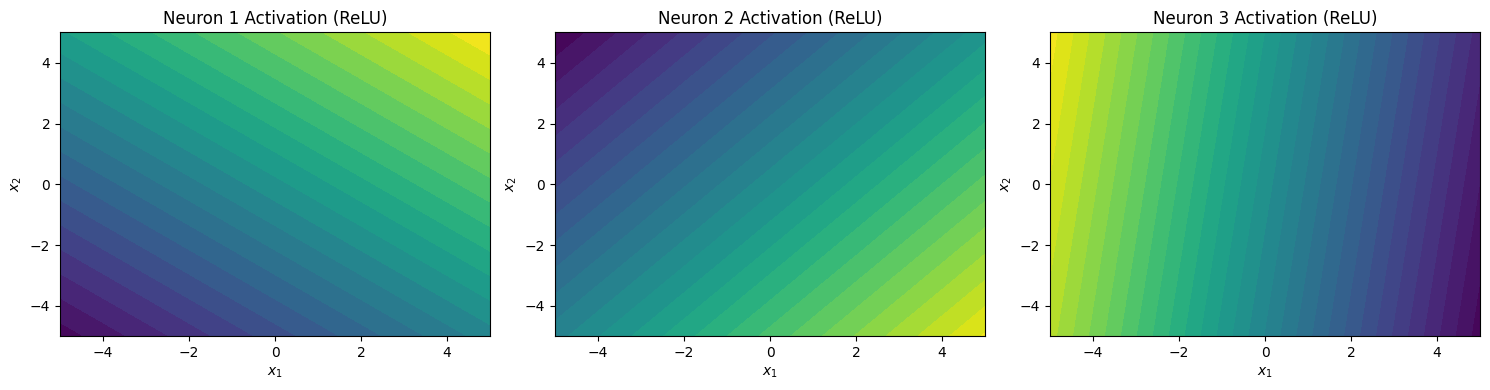

In [6]:
grid_x1, grid_x2 = np.meshgrid(
    np.linspace(-5, 5, 200),
    np.linspace(-5, 5, 200)
)
grid_points = np.c_[grid_x1.ravel(), grid_x2.ravel()]  # shape (40000, 2)



# sigmoid activation
h1 = sigmoid(z1)                   # shape (40000, 3)

# Try without activation for linear output
h1 = z1                        # shape (40000, 3)

# Plot activation map for each hidden neuron
fig, axes = plt.subplots(1, hidden_dim, figsize=(15, 4))
for i in range(hidden_dim):
    ax = axes[i]
    h_vals = h1[:, i].reshape(grid_x1.shape)
    ax.contourf(grid_x1, grid_x2, h_vals, cmap='viridis', levels=30)
    ax.set_title(f'Neuron {i+1} Activation (ReLU)')
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
plt.tight_layout()
plt.show()

# Manual Forward Pass

### Network Architecture

$$
\underbrace{(x_1,x_2)}_{\text{2 inputs}}
\rightarrow
\underbrace{(z_1,z_2,z_3)}_{\text{3 hidden neurons}}
\rightarrow
\underbrace{(h_1,h_2,h_3)}_{\text{ReLU}}
\rightarrow
\underbrace{\hat{y}}_{\text{1 output}}
$$




In [9]:

x_torch = torch.tensor([[1.5, -0.5]], dtype=torch.float32)

# Seed and weight initialization using PyTorch
W1_t = torch.randn(2, 3)
b1_t = torch.randn(1, 3)

W2_t = torch.randn(3, 1)
b2_t = torch.randn(1, 1)

# Activation
def relu(z):
    return torch.maximum(z, torch.tensor(0.0))

# Forward pass
z1_t = x_torch @ W1_t + b1_t   # Linear hidden layer
h_t = relu(z1_t)               # Activation
y_hat_t = h_t @ W2_t + b2_t    # Output layer

# Output
print("Input:", x_torch.numpy())
print("Hidden activations:", h_t.detach().numpy())
print("Output prediction:", y_hat_t.item())

Input: [[ 1.5 -0.5]]
Hidden activations: [[0. 0. 0.]]
Output prediction: 1.9255504608154297


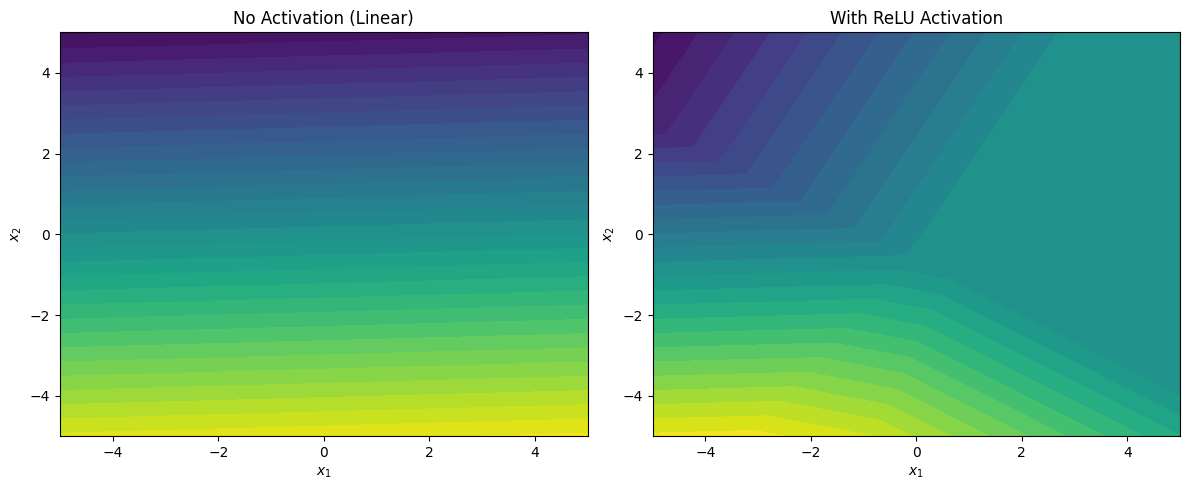

In [10]:
xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_torch = torch.tensor(grid_points, dtype=torch.float32)

# Forward pass WITHOUT activation
z1_no_act = grid_torch @ W1_t + b1_t
y_hat_no_act = (z1_no_act @ W2_t + b2_t).reshape(xx.shape)

# Forward pass WITH ReLU
z1_relu = grid_torch @ W1_t + b1_t
h_relu = relu(z1_relu)
y_hat_relu = (h_relu @ W2_t + b2_t).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear only (no activation)
#cs1 = axes[0].contourf(xx, yy, y_hat_no_act.detach().numpy(), levels=30, cmap='coolwarm')
cs1 = axes[0].contourf(xx, yy, y_hat_no_act.detach().numpy(), levels=30, cmap='viridis')
axes[0].set_title("No Activation (Linear)")
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')

# Non-linear with ReLU
#cs2 = axes[1].contourf(xx, yy, y_hat_relu.detach().numpy(), levels=30, cmap='coolwarm')
cs2 = axes[1].contourf(xx, yy, y_hat_relu.detach().numpy(), levels=30, cmap='viridis')
axes[1].set_title("With ReLU Activation")
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')

plt.tight_layout()
plt.show()

In [11]:
df = pd.read_csv("/content/drive/MyDrive/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [12]:
df['target'] = (df['num'] > 0).astype(int)

features = ['thalach', 'oldpeak']
X_real = df[features].values
y_real = df['target'].values

# Normalize the features
# X_real = (X_real - X_real.mean(axis=0)) / X_real.std(axis=0)

# standardize the features
X_real = (X_real - np.min(X_real, axis=0)) / (np.max(X_real, axis=0) - np.min(X_real, axis=0))

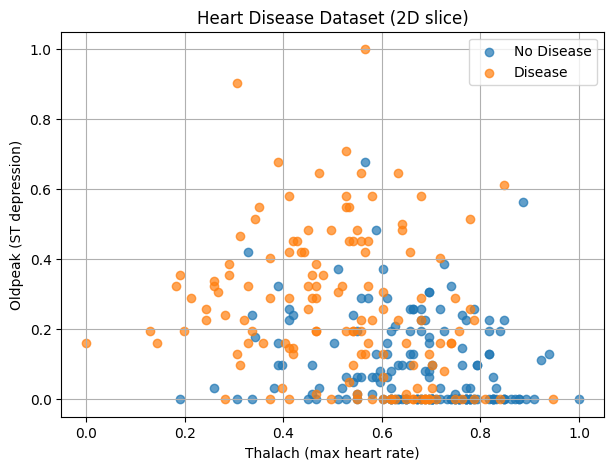

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(X_real[y_real == 0][:, 0], X_real[y_real == 0][:, 1], label='No Disease', alpha=0.7)
plt.scatter(X_real[y_real == 1][:, 0], X_real[y_real == 1][:, 1], label='Disease', alpha=0.7)
plt.xlabel("Thalach (max heart rate)")
plt.ylabel("Oldpeak (ST depression)")
plt.title('Heart Disease Dataset (2D slice)')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
W1_real = np.random.randn(2, 3)    # (2 → 3)
b1_real = np.random.randn(1, 3)    # (1, 3)
W2_real = np.random.randn(3, 1)    # (3 → 1)
b2_real = np.random.randn(1, 1)    # (1, 1)

# ReLU function
def relu(z):
    return np.maximum(0, z)

# Forward pass (no training!)
z1 = np.dot(X_real, W1_real) + b1_real
h1 = relu(z1)
y_logits = np.dot(h1, W2_real) + b2_real

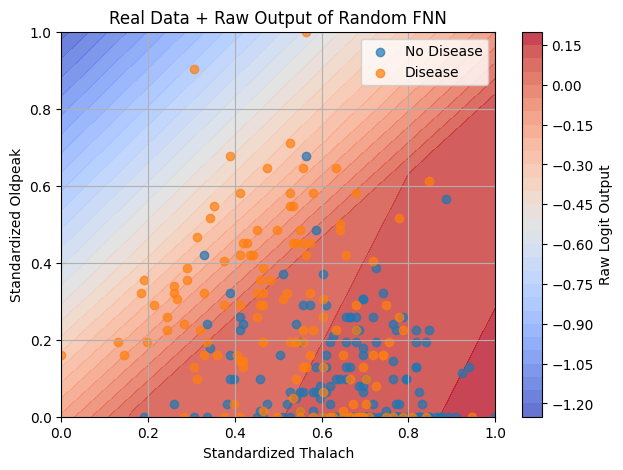

In [15]:
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Forward pass
z1_grid = np.dot(grid_points, W1_real) + b1_real
h1_grid = relu(z1_grid)
y_grid_logits = np.dot(h1_grid, W2_real) + b2_real
y_grid_logits = y_grid_logits.reshape(xx.shape)

# Plot
plt.figure(figsize=(7, 5))

# Contour plot of raw logits
contour = plt.contourf(xx, yy, y_grid_logits, cmap='coolwarm', alpha=0.8, levels=30)

# Decision surface with data points
plt.scatter(X_real[y_real == 0][:, 0], X_real[y_real == 0][:, 1], label='No Disease', alpha=0.7)
plt.scatter(X_real[y_real == 1][:, 0], X_real[y_real == 1][:, 1], label='Disease', alpha=0.7)

# Axes and labels
plt.xlabel('Standardized Thalach')
plt.ylabel('Standardized Oldpeak')
plt.title('Real Data + Raw Output of Random FNN')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

# Explicit colorbar linked to contour plot
plt.colorbar(contour, label="Raw Logit Output")
plt.show()



# Logit

In neural networks, a logit is the raw, unnormalized prediction output by the final linear layer before it is converted into a probability.

# Sigmoid Function In Binary Classification

Binary Classification (Sigmoid): A single logit is passed through the Sigmoid function. A large positive logit becomes a probability close to 1, a large negative logit becomes a probability close to 0, and a logit of exactly 0 maps to a 50% probability.


$$
\text{Probability} = \text{sigmoid}(\text{logit}) = \frac{1}{1 + e^{-\text{logit}}}
$$


In [16]:
def relu(z):
    return np.maximum(0, z)



z1 = X_real @ W1_real + b1_real

h1 = relu(z1)


logits = h1 @ W2_real + b2_real

predictions = np.where(logits >= 0, 1, 0)

model_accuracy = np.mean(predictions.flatten() == y_real.flatten())

print(f"Model Accuracy: {model_accuracy:.4f}")

Model Accuracy: 0.3234


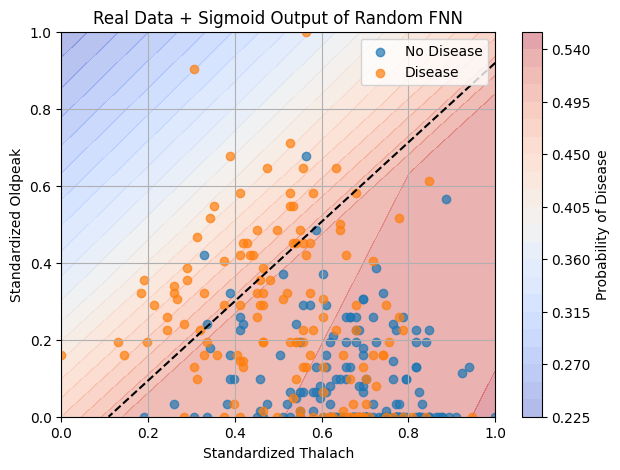

In [17]:
y_grid_probs = sigmoid(y_grid_logits)

# Plot
plt.figure(figsize=(7, 5))
contour = plt.contourf(xx, yy, y_grid_probs, cmap='coolwarm', alpha=0.4, levels=30)
plt.contour(xx, yy, y_grid_probs, levels=[0.5], colors='black', linestyles='--')  # Decision boundary

# Scatter original data
plt.scatter(X_real[y_real == 0][:, 0], X_real[y_real == 0][:, 1], label='No Disease', alpha=0.7)
plt.scatter(X_real[y_real == 1][:, 0], X_real[y_real == 1][:, 1], label='Disease', alpha=0.7)

# Labels and formatting
plt.xlabel('Standardized Thalach')
plt.ylabel('Standardized Oldpeak')
plt.title('Real Data + Sigmoid Output of Random FNN')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.colorbar(contour, label="Probability of Disease")  # <- attach explicitly
plt.show()